# Explore here

In [34]:
# Your code here
from utils import db_connect
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
engine = db_connect()
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split



ab_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
ab_data.to_csv("../data/raw/sin_procesar.csv", index = False)
ab_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
ab_data.describe

<bound method NDFrame.describe of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

     

In [12]:
ab_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [13]:
ab_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [14]:
ab_data.drop(["id", "name", "host_name", "last_review", "reviews_per_month"], axis = 1, inplace = True)
ab_data.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


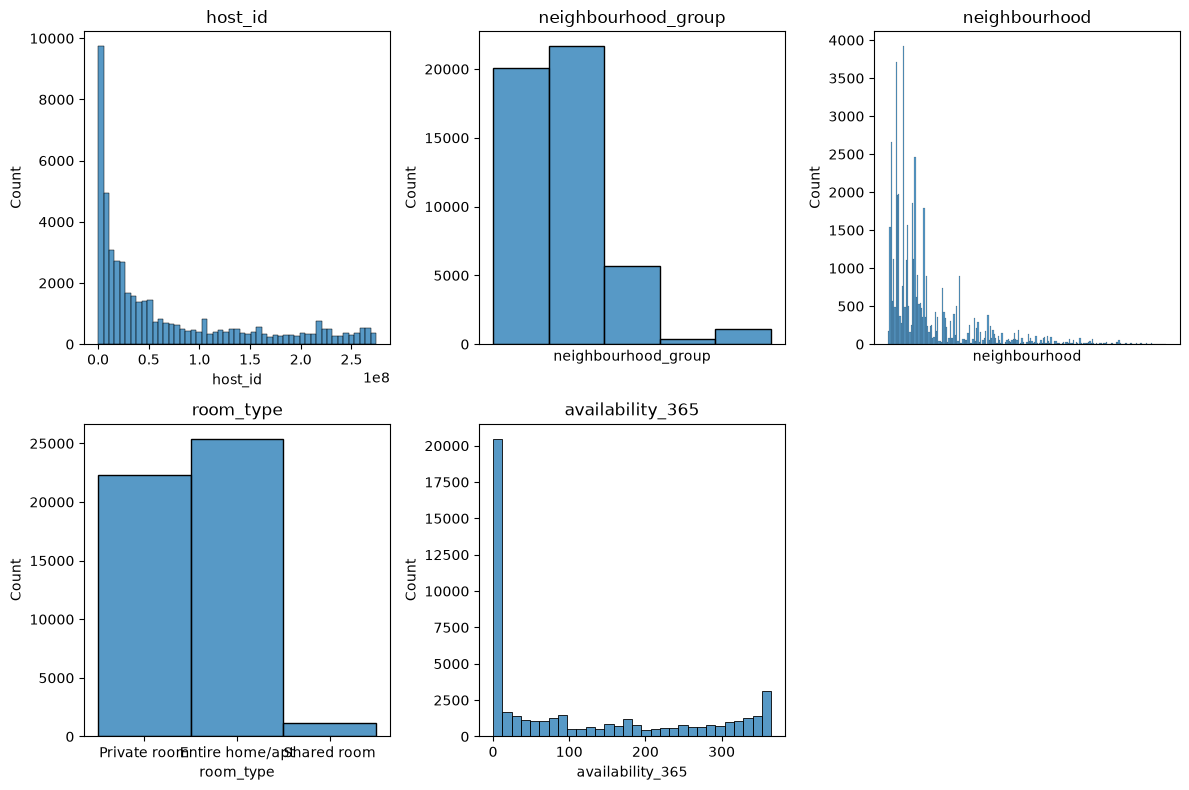

In [15]:
#análisis de variables univariadas
#categóricas
fig, axis = plt.subplots(2, 3, figsize=(12, 8))

columns = [
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "availability_365"
]

axes = axis.flatten()

for ax, col in zip(axes, columns):

    sns.histplot(
        data=ab_data,
        x=col,
        ax=ax
    )

    ax.set_title(col)

    if col in ["neighbourhood_group", "neighbourhood"]:
        ax.set_xticks([])

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

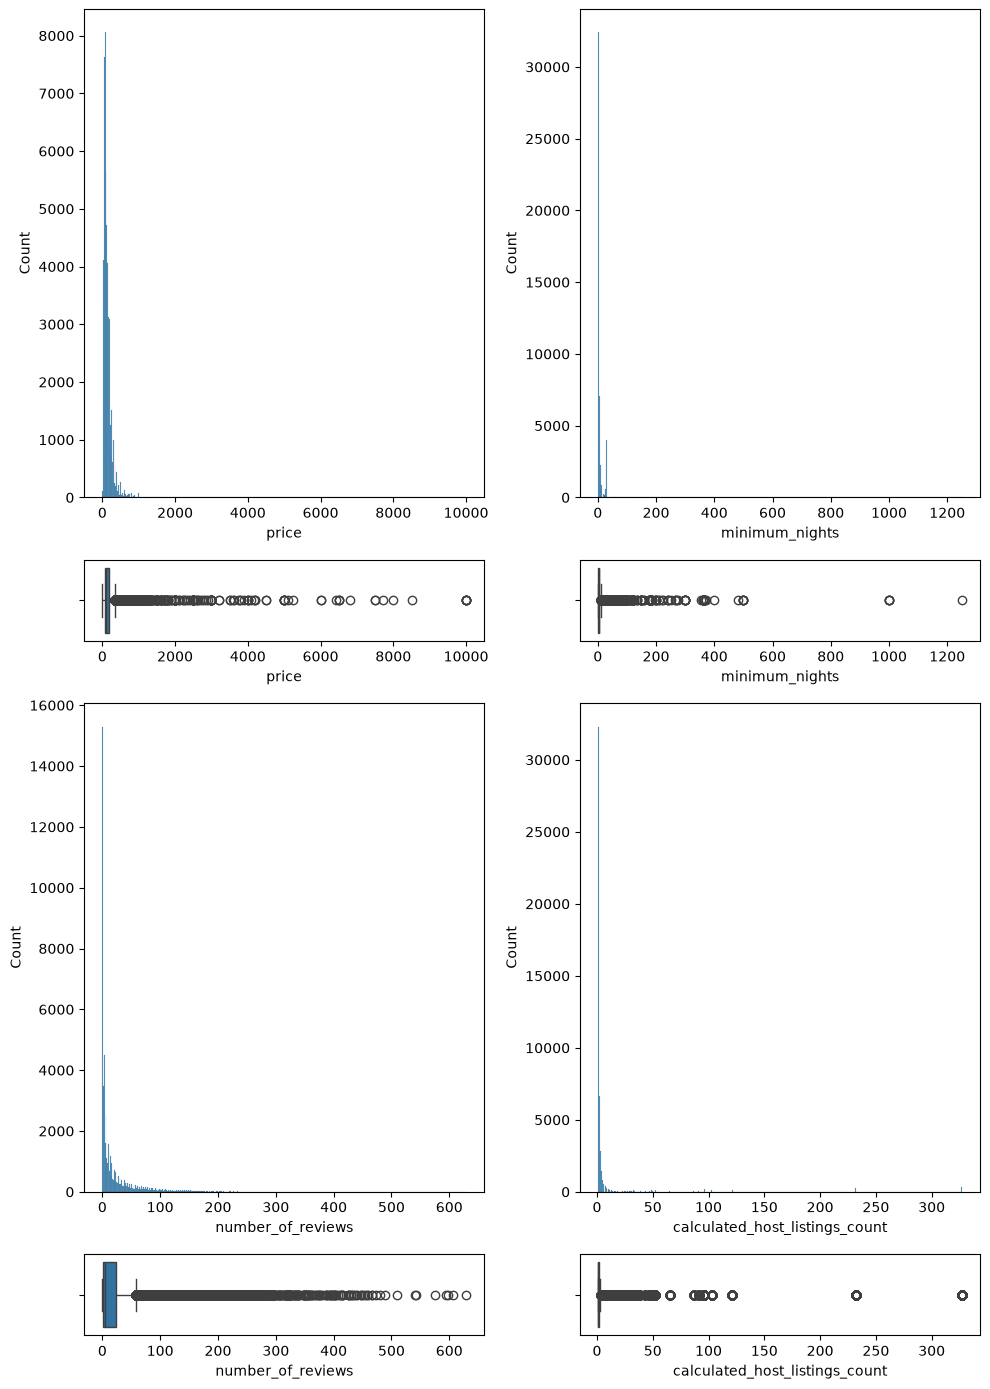

In [16]:
#Númericas
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "calculated_host_listings_count"
]

fig, axis = plt.subplots(
    4, 2,
    figsize=(10, 14),
    gridspec_kw={"height_ratios": [6, 1, 6, 1]}
)

positions = [
    ((0,0),(1,0)),
    ((0,1),(1,1)),
    ((2,0),(3,0)),
    ((2,1),(3,1))
]

for col, ((h_row,h_col),(b_row,b_col)) in zip(numeric_cols, positions):

    sns.histplot(
        data=ab_data,
        x=col,
        ax=axis[h_row, h_col]
    )

    sns.boxplot(
        data=ab_data,
        x=col,
        ax=axis[b_row, b_col]
    )

plt.tight_layout()
plt.show()

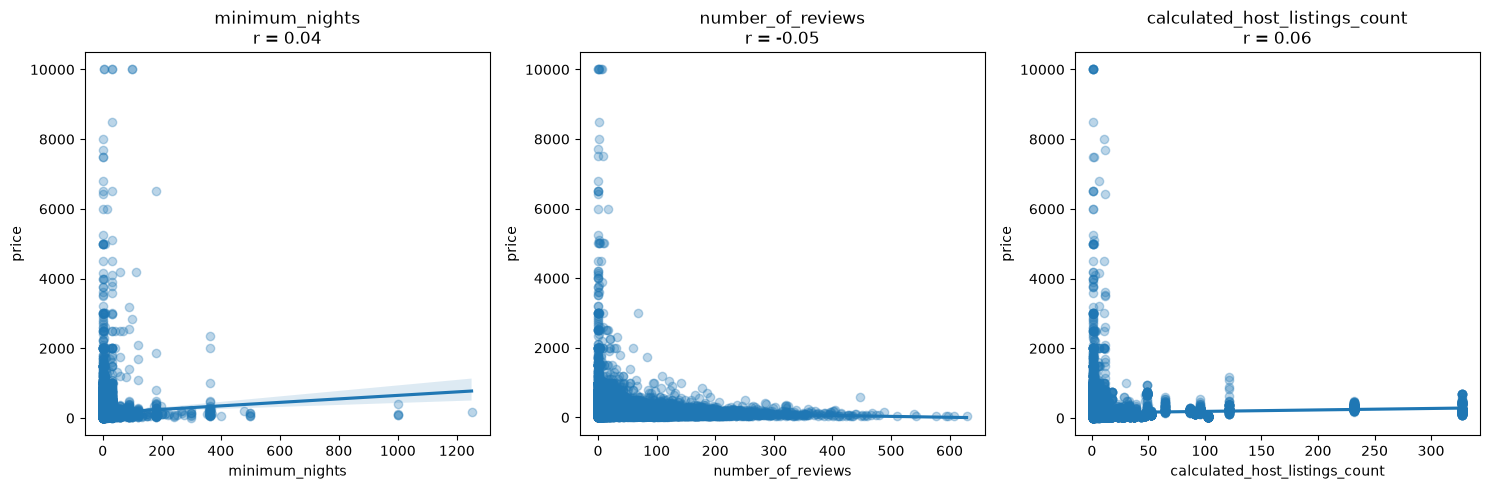

In [17]:
#analisis de variables multivariadas
#númerico-númerico

ffig, axis = plt.subplots(
    1, 3,
    figsize=(15,5)
)

variables = [
    "minimum_nights",
    "number_of_reviews",
    "calculated_host_listings_count"
]

for ax, col in zip(axis, variables):

    sns.regplot(
        data=ab_data,
        x=col,
        y="price",
        scatter_kws={"alpha":0.3},
        ax=ax
    )

    corr = ab_data["price"].corr(ab_data[col])

    ax.set_title(
        f"{col}\nr = {corr:.2f}"
    )

plt.tight_layout()
plt.show()

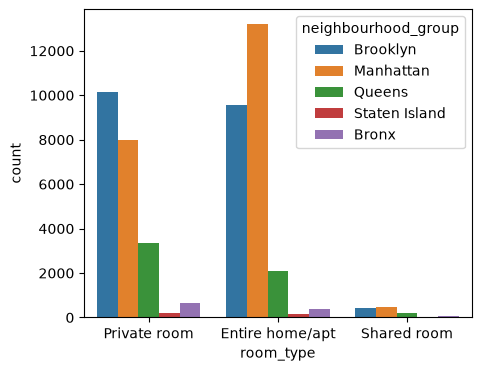

In [18]:
#categórico-categórico
fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = ab_data, x = "room_type", hue = "neighbourhood_group")


plt.show()

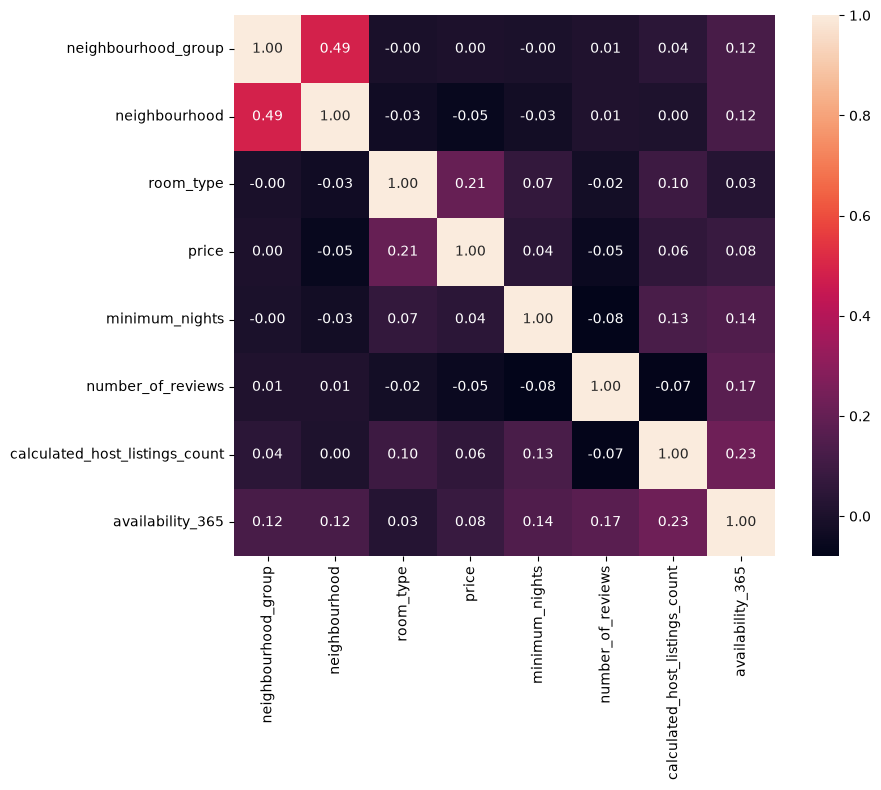

In [19]:
#númerico-categórico

encoded_data = ab_data.copy()

for col in [
    "room_type",
    "neighbourhood_group",
    "neighbourhood"
]:
    encoded_data[col] = pd.factorize(encoded_data[col])[0]

corr_matrix = encoded_data[
    [
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "calculated_host_listings_count",
        "availability_365"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.tight_layout()
plt.show()

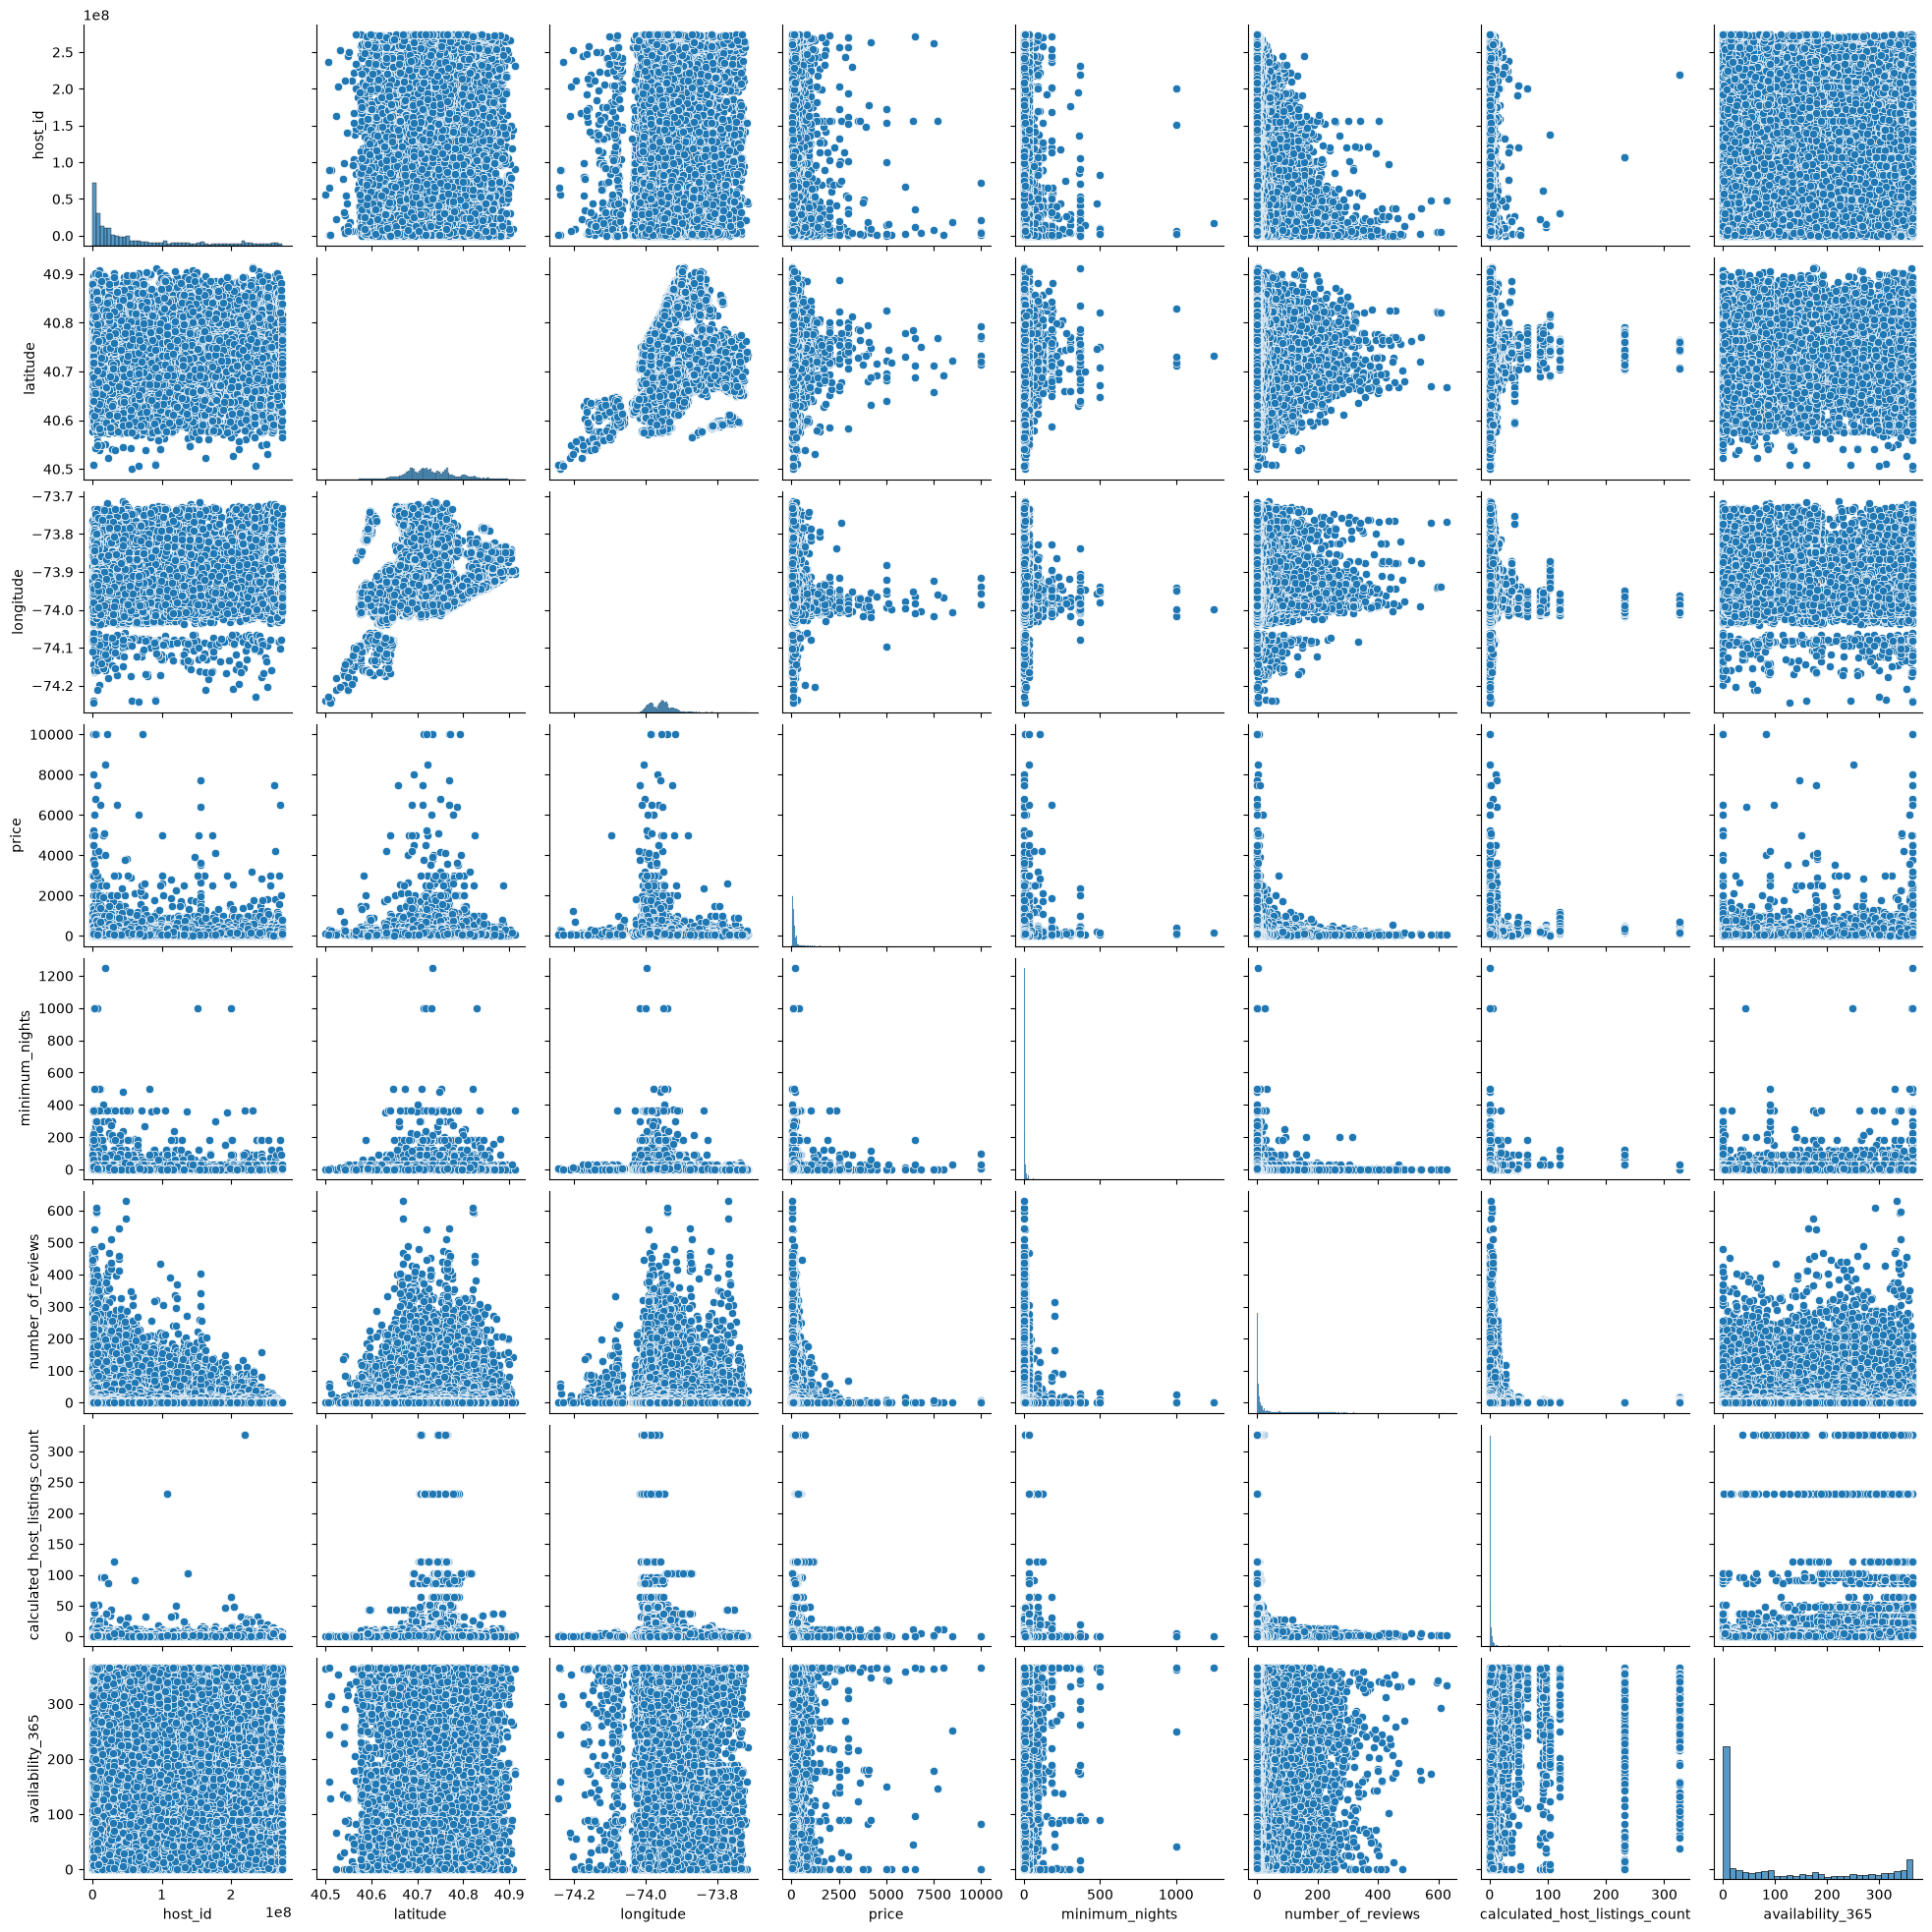

In [20]:
sns.pairplot(data = ab_data)

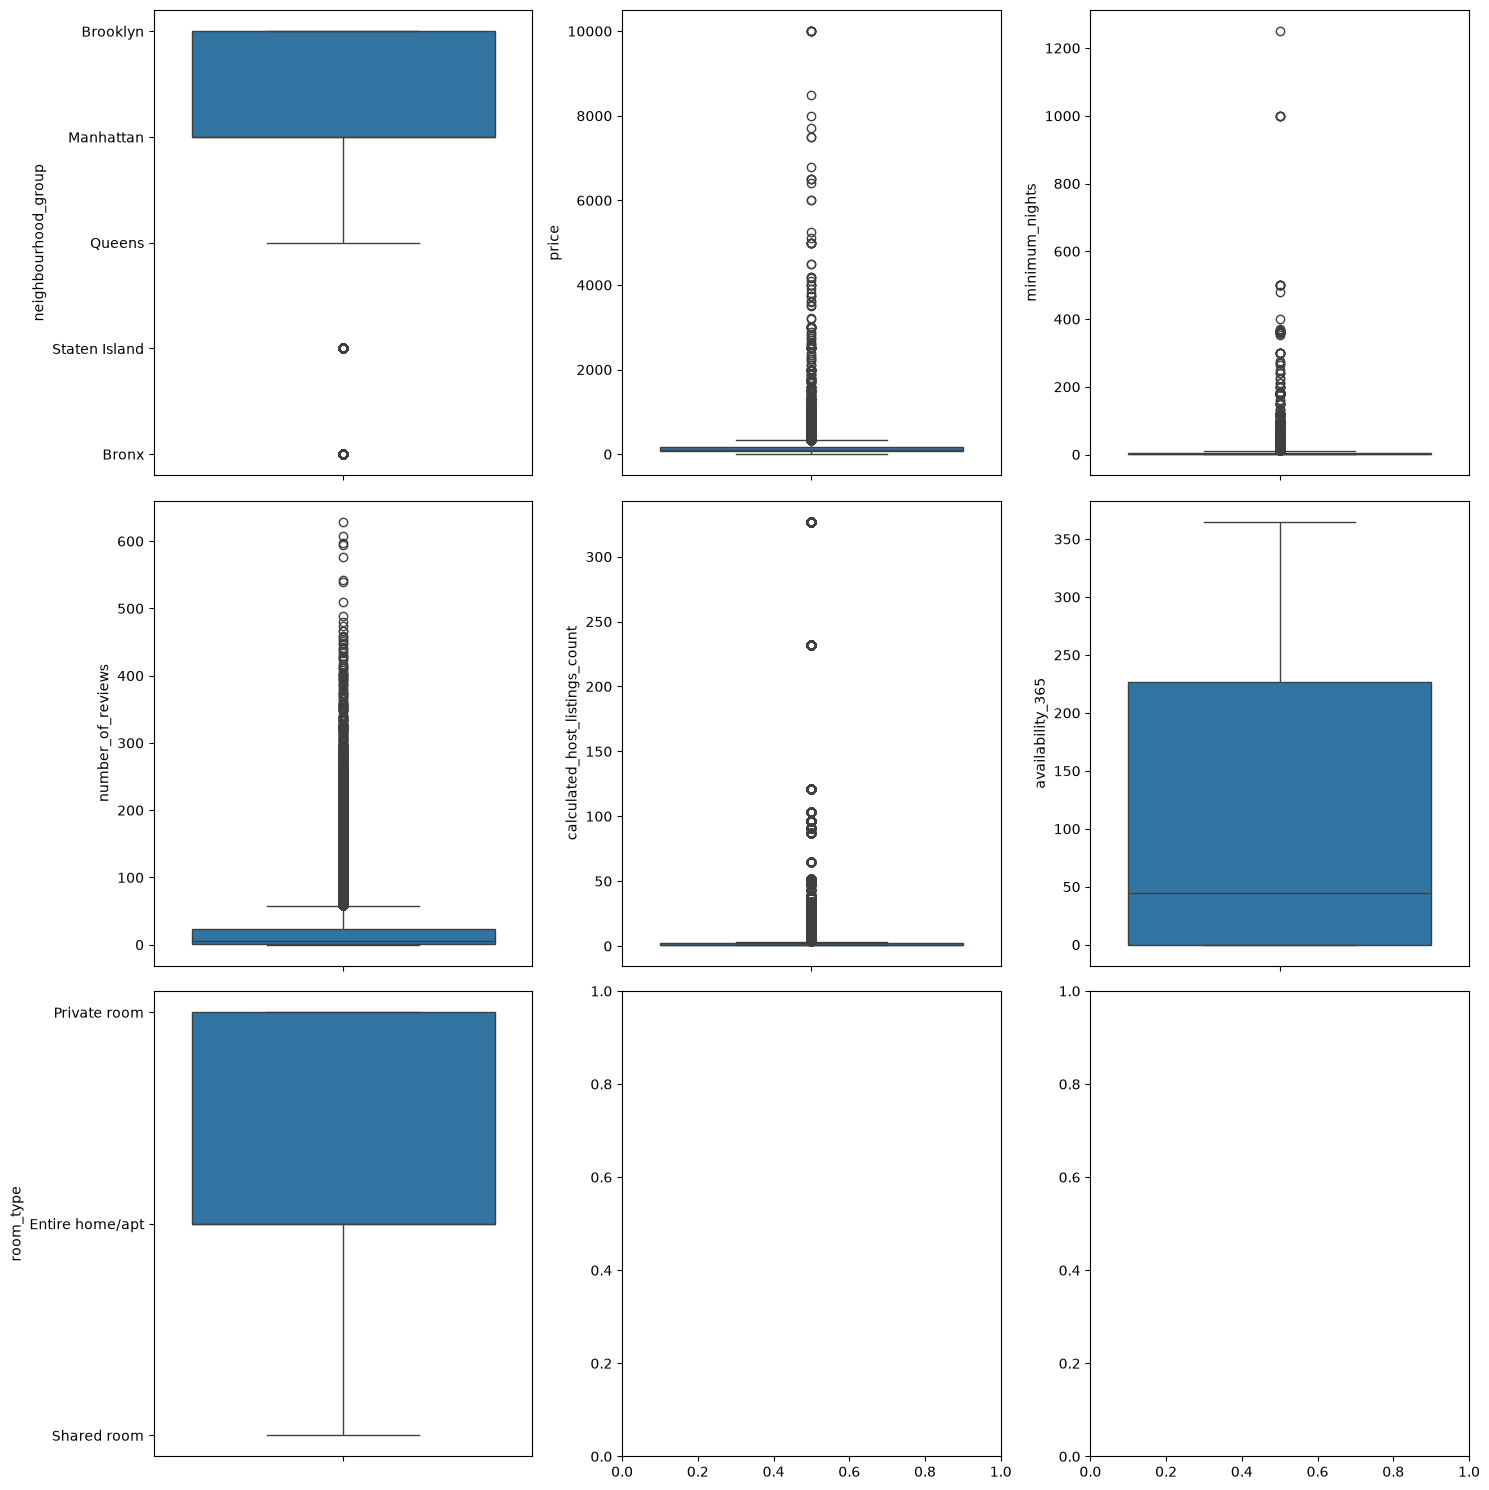

In [21]:
fig, axes = plt.subplots(3, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = ab_data, y = "neighbourhood_group")
sns.boxplot(ax = axes[0, 1], data = ab_data, y = "price")
sns.boxplot(ax = axes[0, 2], data = ab_data, y = "minimum_nights")
sns.boxplot(ax = axes[1, 0], data = ab_data, y = "number_of_reviews")
sns.boxplot(ax = axes[1, 1], data = ab_data, y = "calculated_host_listings_count")
sns.boxplot(ax = axes[1, 2], data = ab_data, y = "availability_365")
sns.boxplot(ax = axes[2, 0], data = ab_data, y = "room_type")

plt.tight_layout()

plt.show()

In [22]:
#Limpieza de valores atípicos
price_stats = ab_data["price"].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [23]:
price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr
print(upper_limit, lower_limit)


334.0 -90.0


In [24]:
ab_data = ab_data[
    (ab_data["price"] > 0) &
    (ab_data["price"] <= upper_limit)
]


In [25]:
nights_stats = ab_data["minimum_nights"].describe()
nights_stats

count    45912.000000
mean         6.937968
std         19.859505
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [26]:
nights_iqr = nights_stats["50%"]

upper_limit_night = nights_stats["75%"] + 1.5 * nights_iqr
lower_limit_night = nights_stats["25%"] - 1.5 * nights_iqr
print(upper_limit_night, lower_limit_night)

8.0 -2.0


In [27]:
ab_data = ab_data[
    (ab_data["minimum_nights"] > 0) &
    (ab_data["minimum_nights"] <= upper_limit_night)
]

In [28]:
review_stats = ab_data["number_of_reviews"].describe()
review_stats


count    39157.000000
mean        26.643435
std         47.726965
min          0.000000
25%          1.000000
50%          7.000000
75%         29.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [29]:
ab_data = ab_data[
    (ab_data["number_of_reviews"] > 0) &
    (ab_data["number_of_reviews"] <= upper_limit_night)]

In [30]:

review_iqr = review_stats["75%"] - review_stats["25%"]

upper_limit_reviews = review_stats["75%"] + 1.5 * review_iqr
lower_limit_reviews = review_stats["25%"] - 1.5 * review_iqr

print(upper_limit_reviews, lower_limit_reviews)

71.0 -41.0


In [31]:
hostlist_stats = ab_data["calculated_host_listings_count"].describe()
hostlist_stats

count    14582.000000
mean         4.103827
std         27.664251
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [32]:
hostlist_iqr = hostlist_stats["75%"] - hostlist_stats["25%"]

upper_limit = hostlist_stats["75%"] + 1.5 * hostlist_iqr
lower_limit = hostlist_stats["25%"] - 1.5 * hostlist_iqr

total_data = ab_data[ab_data["calculated_host_listings_count"] > 4]

In [33]:
ab_data_data.isnull().sum().sort_values(ascending = False)

NameError: name 'ab_data_data' is not defined

In [ ]:
num_variables = ["number_of_reviews", "minimum_nights", "calculated_host_listings_count", 
                 "availability_365", "neighbourhood_group", "room_type"]
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
df_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
df_scal["price"] = total_data["price"]
df_scal.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
200,0.714286,0.857143,0.000000,1.000000,0.5,0.0,140
330,0.142857,0.285714,0.071429,0.164384,0.0,0.0,249
680,0.285714,0.285714,0.071429,0.164384,0.0,0.0,249
681,0.714286,0.285714,0.071429,0.164384,0.0,0.0,299
682,0.428571,0.285714,0.071429,0.221918,0.0,0.0,179


In [ ]:
X = df_scal.drop("price", axis = 1)
y = df_scal["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,room_type
0,0.428571,0.142857,1.000000,0.5
1,0.000000,0.000000,0.086957,0.0
2,0.571429,0.142857,1.000000,0.5
3,1.000000,0.142857,0.000000,0.0
4,0.000000,0.000000,0.018634,0.0


In [ ]:
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)